## Cell 1 — Imports

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
import time
print("All packages imported successfully.")

All packages imported successfully.


## Cell 2 — Build 12-Qubit Circuit

Random Quantum Circuit Generated
Seed             : 60066
Number of Qubits : 12
Circuit Depth    : 18
Total Gates      : 162


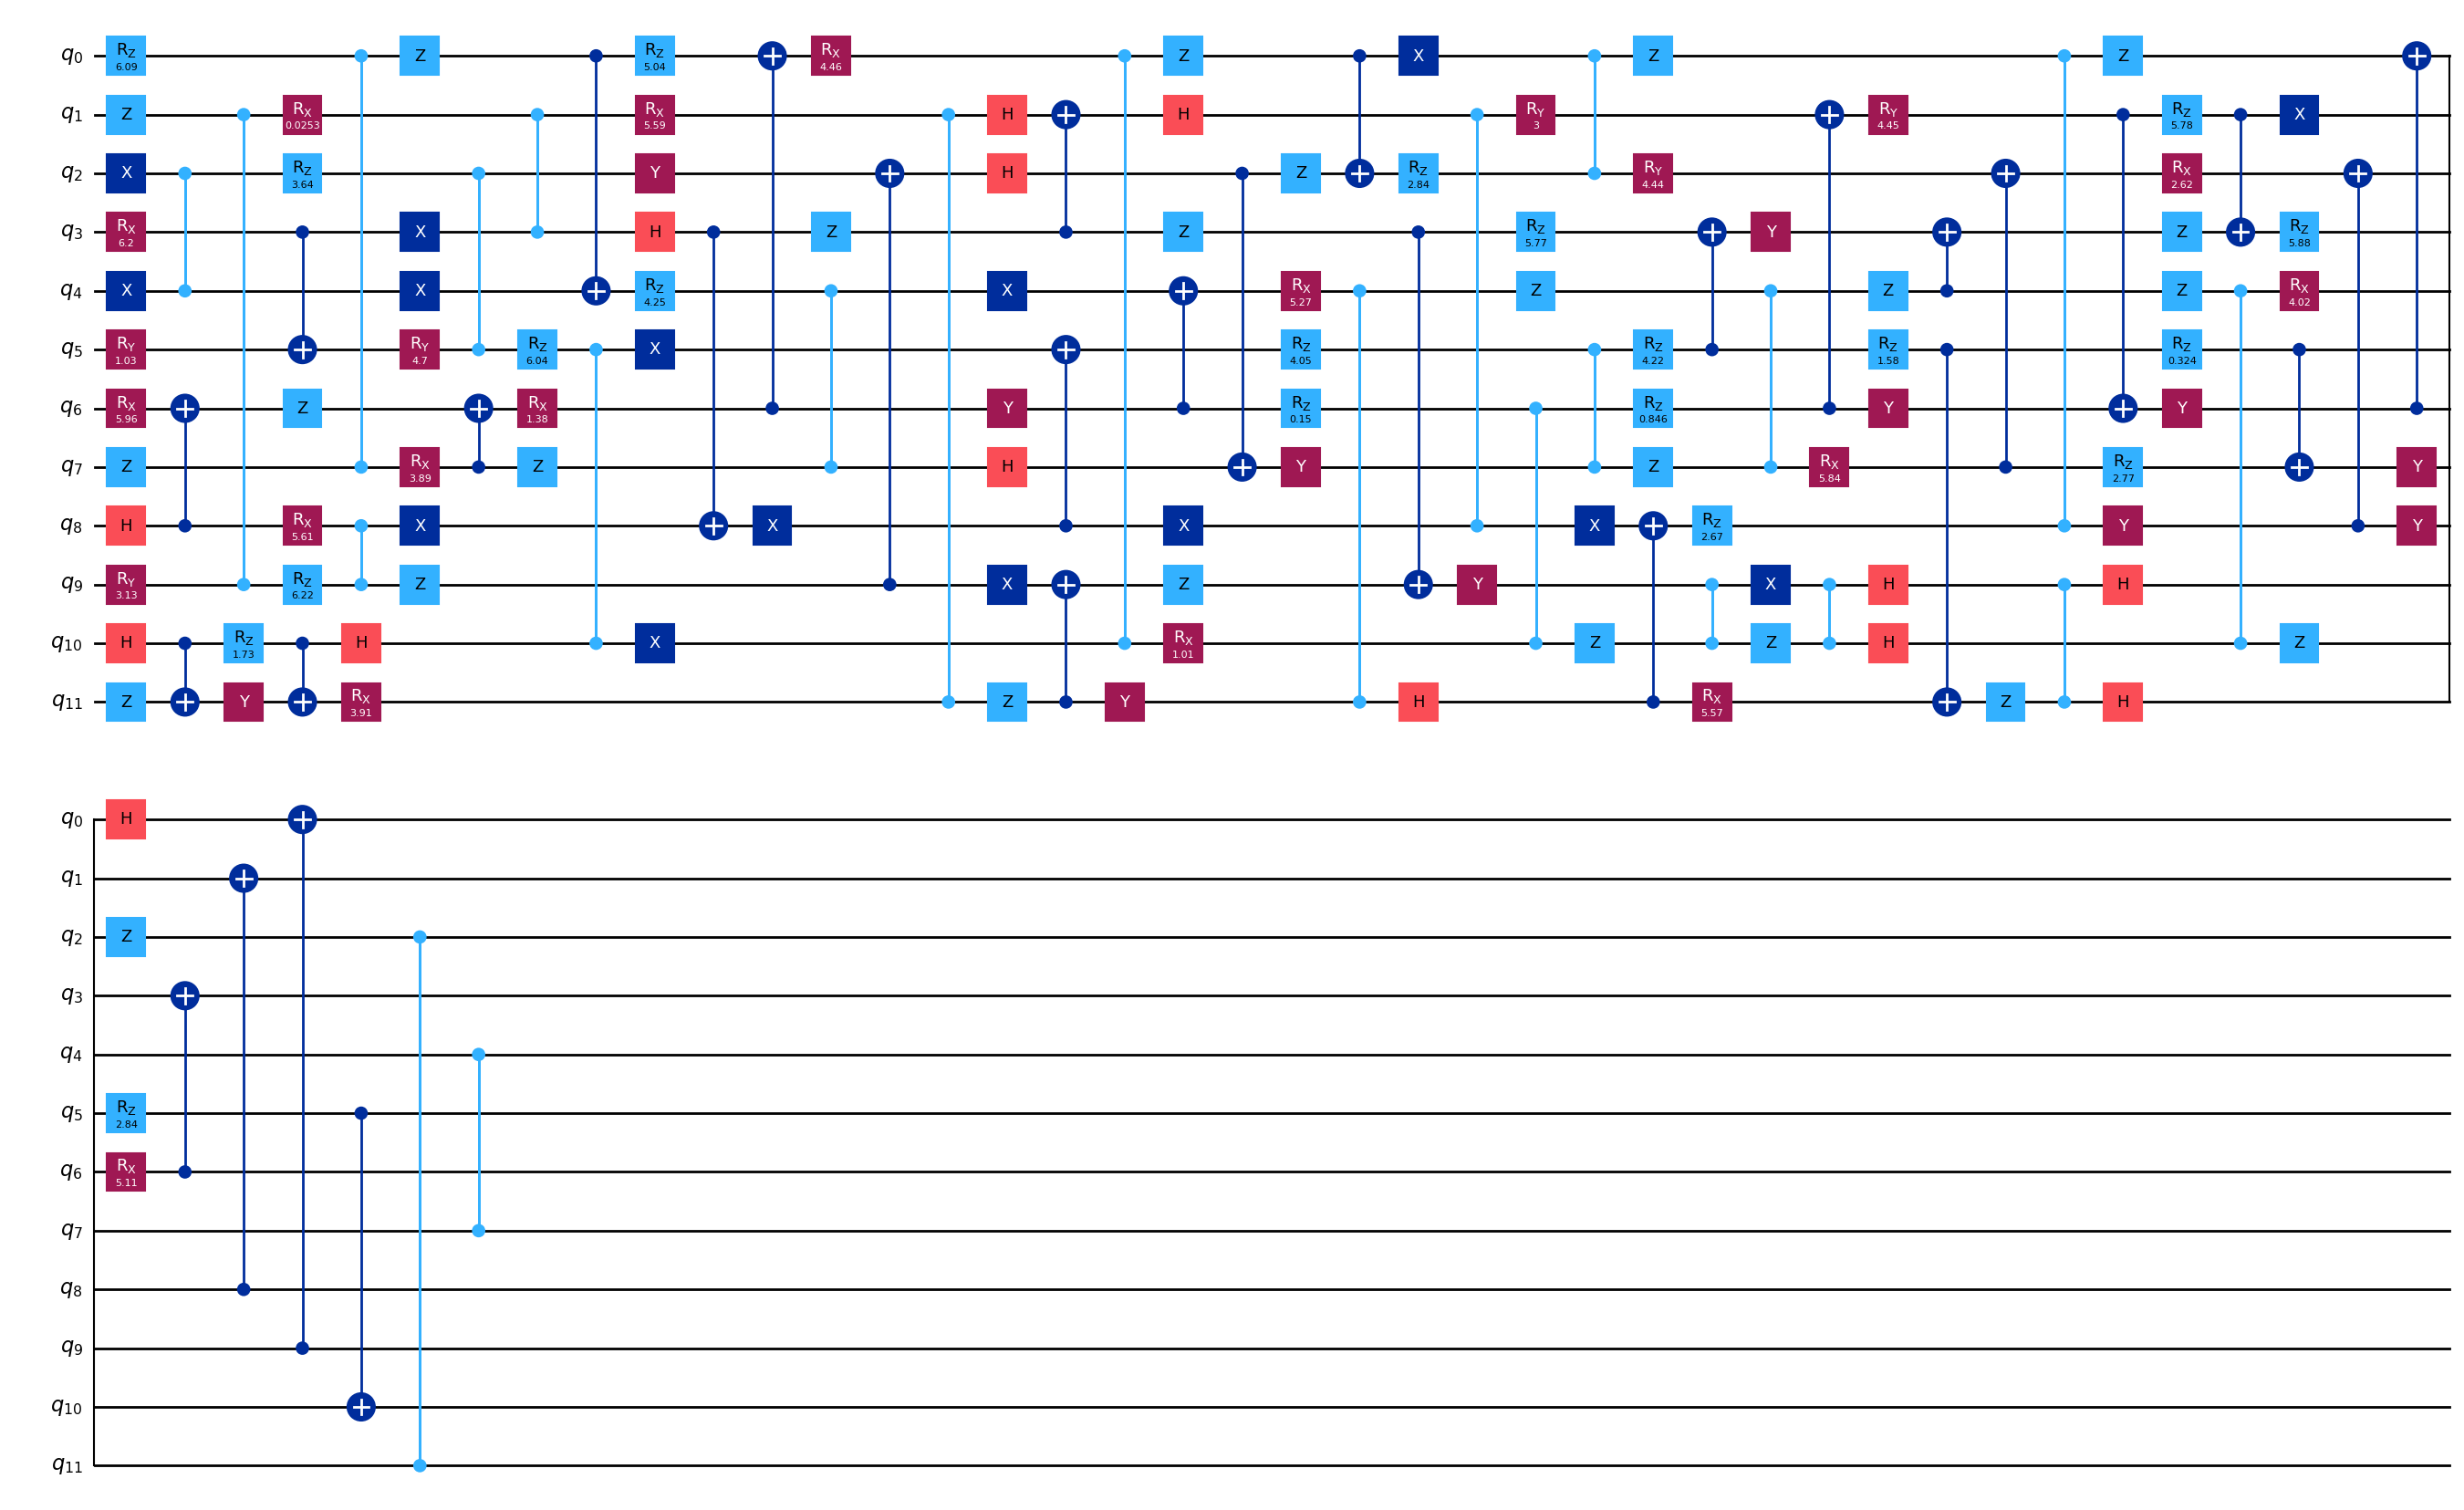

In [19]:
import random
import numpy as np
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

def generate_random_circuit():
    seed = random.randint(0, 99999)
    random.seed(seed)
    np.random.seed(seed)
    
    num_qubits = random.randint(4, 12)
    depth = random.randint(5, 10)
    qc = QuantumCircuit(num_qubits)
    
    single_gates = ['h', 'x', 'y', 'z', 'rx', 'ry', 'rz']
    two_gates = ['cx', 'cz']
    
    for _ in range(depth):
        for q in range(num_qubits):
            gate = random.choice(single_gates)
            if gate in ['rx', 'ry', 'rz']:
                theta = np.random.uniform(0, 2 * np.pi)
                getattr(qc, gate)(theta, q)
            else:
                getattr(qc, gate)(q)
        
        qubits = random.sample(range(num_qubits), num_qubits)
        for i in range(0, num_qubits - 1, 2):
            gate = random.choice(two_gates)
            if gate == 'cx':
                qc.cx(qubits[i], qubits[i + 1])
            else:
                qc.cz(qubits[i], qubits[i + 1])
    
    print("=" * 50)
    print("Random Quantum Circuit Generated")
    print(f"Seed             : {seed}")
    print(f"Number of Qubits : {num_qubits}")
    print(f"Circuit Depth    : {qc.depth()}")
    print(f"Total Gates      : {len(qc.data)}")
    print("=" * 50)
    
    return qc

qc = generate_random_circuit()

qc.draw("mpl", fold=40)

## Cell 3 — Convert Circuit to Qubit Interaction Graph

In [4]:
def circuit_to_graph(circuit):
   
    G = nx.Graph()
    for q in range(circuit.num_qubits):
        G.add_node(q)
    for inst in circuit.data:
        if len(inst.qubits) == 2:
            q0 = circuit.qubits.index(inst.qubits[0])
            q1 = circuit.qubits.index(inst.qubits[1])
            gate = inst.operation.name
            if G.has_edge(q0, q1):
                G[q0][q1]['gate'] += '+' + gate
            else:
                G.add_edge(q0, q1, gate=gate)
    return G

G = circuit_to_graph(qc)
print(f'Nodes: {list(G.nodes())}')
print(f'Edges: {list(G.edges())}')

Nodes: [0, 1, 2, 3, 4]
Edges: [(0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4), (2, 3), (3, 4)]


## Cell 4 — Brute Force: Strict Balanced Partition (6 vs 6)

In [5]:
def brute_force_partition(G, num_qubits):
   
    all_qubits   = set(range(num_qubits))
    half         = num_qubits // 2   # strictly 6

    best_partition    = None
    best_cut_edges    = None
    minimum_cut_count = float('inf')
    total_combos      = 0

    start = time.time()

    for subset in combinations(all_qubits, half):   # always picks exactly 6
        total_combos += 1
        partA = set(subset)
        partB = all_qubits - partA               # automatically the other 6

        cut_edges = [
            (u, v, data['gate'])
            for u, v, data in G.edges(data=True)
            if (u in partA) != (v in partA)      # XOR: one node in each group
        ]

        if len(cut_edges) < minimum_cut_count:
            minimum_cut_count = len(cut_edges)
            best_partition    = (partA, partB)
            best_cut_edges    = cut_edges

    runtime = time.time() - start
    return best_partition, best_cut_edges, minimum_cut_count, runtime, total_combos


print('Running Brute Force (evaluating all C(12,6) = 924 balanced partitions)...')
best_partition, best_cut_edges, minimum_cut_count, bf_runtime, total_combos = \
    brute_force_partition(G, qc.num_qubits)

partA, partB = best_partition

print()
print('=' * 52)
print('   BRUTE FORCE RESULTS')
print('=' * 52)
print(f'  Partitions evaluated : {total_combos}')
print(f'  Runtime              : {bf_runtime:.4f} seconds')
print(f'  Minimum Cut Count    : {minimum_cut_count}')
print()
print(f'  Group A ({len(partA)} qubits) : {sorted(partA)}')
print(f'  Group B ({len(partB)} qubits) : {sorted(partB)}')
print()
print('  Cut Gates:')
for u, v, gate in best_cut_edges:
    print(f'    {gate.upper():5s}  q{u}  <-->  q{v}')
print('=' * 52)

Running Brute Force (evaluating all C(12,6) = 924 balanced partitions)...

   BRUTE FORCE RESULTS
  Partitions evaluated : 10
  Runtime              : 0.0012 seconds
  Minimum Cut Count    : 4

  Group A (2 qubits) : [0, 1]
  Group B (3 qubits) : [2, 3, 4]

  Cut Gates:
    CZ+CX  q0  <-->  q2
    CX     q0  <-->  q3
    CX     q1  <-->  q3
    CZ+CX  q1  <-->  q4


## Cell 5 — Qubit Interaction Graph (Simple Layout)

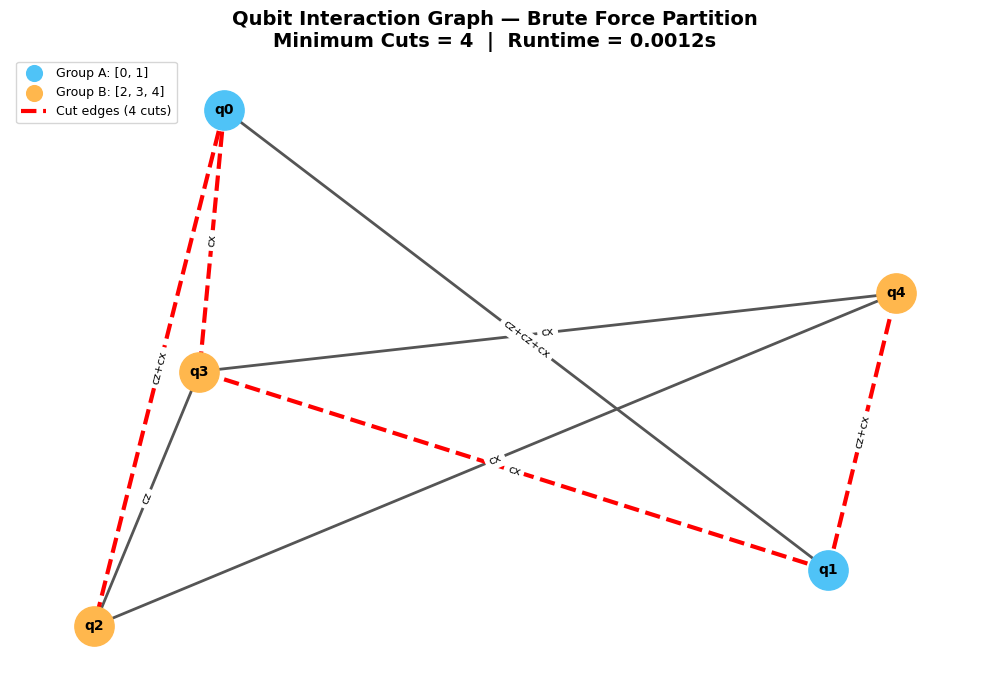

In [6]:
def draw_interaction_graph(G, partA, partB, cut_edges_list,
                           title="Qubit Interaction Graph"):

    fig, ax = plt.subplots(figsize=(10, 7))

    # Use a layout that spaces nodes nicely
    pos = nx.spring_layout(G, seed=42, k=1.5)

    cut_edge_set = {(u, v) for u, v, _ in cut_edges_list} | \
                   {(v, u) for u, v, _ in cut_edges_list}

    internal_edges = [(u, v) for u, v in G.edges()
                      if (u, v) not in cut_edge_set]

    cut_edges_draw = [(u, v) for u, v in G.edges()
                      if (u, v) in cut_edge_set]

    # Draw Group A nodes
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=list(partA),
        node_color="#4fc3f7",
        node_size=800,
        label=f"Group A: {sorted(partA)}",
        ax=ax
    )

    # Draw Group B nodes
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=list(partB),
        node_color="#ffb74d",
        node_size=800,
        label=f"Group B: {sorted(partB)}",
        ax=ax
    )

    # Draw internal edges
    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        width=2.0,
        edge_color="#555555",
        ax=ax
    )

    # Draw cut edges
    nx.draw_networkx_edges(
        G, pos,
        edgelist=cut_edges_draw,
        width=3.0,
        edge_color="red",
        style="dashed",
        label=f"Cut edges ({len(cut_edges_list)} cuts)",
        ax=ax
    )

    # Draw node labels
    nx.draw_networkx_labels(
        G, pos,
        labels={n: f"q{n}" for n in G.nodes()},
        font_size=10,
        font_weight="bold",
        ax=ax
    )

    # Draw gate labels
    edge_labels = nx.get_edge_attributes(G, "gate")

    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=8,
        ax=ax
    )

    # Legend
    ax.legend(loc="upper left", fontsize=9, markerscale=0.4)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

    plt.tight_layout()
    plt.show()


draw_interaction_graph(
    G,
    partA,
    partB,
    best_cut_edges,
    title=f"Qubit Interaction Graph — Brute Force Partition\n"
          f"Minimum Cuts = {minimum_cut_count}  |  Runtime = {bf_runtime:.4f}s"
)

## Cell 6 — Extract and Display Subcircuits

Subcircuit A  —  qubits [0, 1]
  Gates: 15  |  Depth: 9


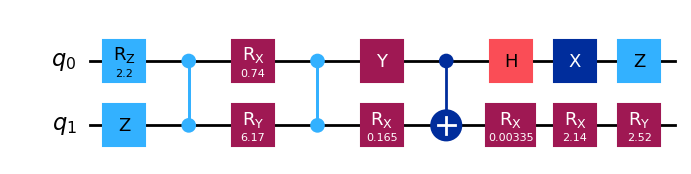

In [7]:
def extract_subcircuit(circuit, qubit_group, cut_edges):
    
    sorted_group = sorted(qubit_group)
    qubit_map    = {old: new for new, old in enumerate(sorted_group)}
    sub_qc       = QuantumCircuit(len(sorted_group))
    cut_pairs    = {(u, v) for u, v, _ in cut_edges} | \
                   {(v, u) for u, v, _ in cut_edges}

    for inst in circuit.data:
        idxs = [circuit.qubits.index(q) for q in inst.qubits]

        if len(idxs) == 1 and idxs[0] in qubit_group:
            sub_qc.append(inst.operation, [qubit_map[idxs[0]]])

        elif len(idxs) == 2:
            q0, q1 = idxs
            if q0 in qubit_group and q1 in qubit_group:
                if (q0, q1) not in cut_pairs:
                    sub_qc.append(inst.operation,
                                  [qubit_map[q0], qubit_map[q1]])
    return sub_qc, sorted_group


sub_A, qubits_A = extract_subcircuit(qc, partA, best_cut_edges)
sub_B, qubits_B = extract_subcircuit(qc, partB, best_cut_edges)

print(f'Subcircuit A  —  qubits {qubits_A}')
print(f'  Gates: {len(sub_A.data)}  |  Depth: {sub_A.depth()}')
sub_A.draw('mpl')

Subcircuit B  —  qubits [2, 3, 4]
  Gates: 21  |  Depth: 9


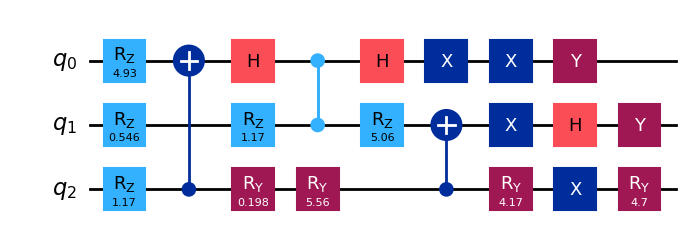

In [8]:
print(f'Subcircuit B  —  qubits {qubits_B}')
print(f'  Gates: {len(sub_B.data)}  |  Depth: {sub_B.depth()}')
sub_B.draw('mpl')

## Cell 7 — Approximate Reconstruction

Reconstructed Circuit (cut gates removed):
  Original depth     : 12
  Reconstructed depth: 9
  Gates removed      : 6


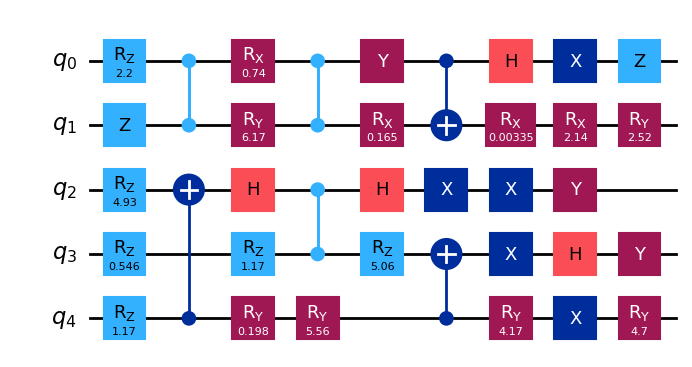

In [9]:
def reconstruct_circuit(circuit, cut_edges):
    
    cut_pairs     = {(u, v) for u, v, _ in cut_edges} | \
                    {(v, u) for u, v, _ in cut_edges}
    reconstructed = QuantumCircuit(circuit.num_qubits)

    for inst in circuit.data:
        idxs = [circuit.qubits.index(q) for q in inst.qubits]
        if len(idxs) == 2 and tuple(idxs) in cut_pairs:
            continue   # skip cut gates
        reconstructed.append(inst.operation, idxs)

    return reconstructed


reconstructed_qc = reconstruct_circuit(qc, best_cut_edges)

print('Reconstructed Circuit (cut gates removed):')
print(f'  Original depth     : {qc.depth()}')
print(f'  Reconstructed depth: {reconstructed_qc.depth()}')
print(f'  Gates removed      : {len(qc.data) - len(reconstructed_qc.data)}')
reconstructed_qc.draw('mpl', fold=40)

## Cell 8 — Fidelity

In [10]:
print('Computing statevectors...')
original_sv      = Statevector.from_instruction(qc)
reconstructed_sv = Statevector.from_instruction(reconstructed_qc)
bf_fidelity      = state_fidelity(original_sv, reconstructed_sv)

print()
print('=' * 40)
print('  FIDELITY RESULT')
print('=' * 40)
print(f'  Fidelity = {bf_fidelity:.6f}')
print()
if bf_fidelity > 0.99:
    print('  Very high — cuts had minimal impact.')
elif bf_fidelity > 0.80:
    print('  Moderate — some entanglement lost at cuts.')
else:
    print('  Low — significant entanglement lost at cuts.')
print('=' * 40)
print()
print('Interpretation:')
print('  Fidelity < 1.0 = entanglement lost at cut gates.')
print('  True reconstruction (Pauli decomposition) gives fidelity = 1.0')
print('  at the cost of classical post-processing overhead.')

Computing statevectors...

  FIDELITY RESULT
  Fidelity = 0.011007

  Low — significant entanglement lost at cuts.

Interpretation:
  Fidelity < 1.0 = entanglement lost at cut gates.
  True reconstruction (Pauli decomposition) gives fidelity = 1.0
  at the cost of classical post-processing overhead.


In [ ]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import DensityMatrix, Statevector, state_fidelity

noise_model = NoiseModel()
error1 = depolarizing_error(0.001, 1)
error2 = depolarizing_error(0.01, 2)
noise_model.add_all_qubit_quantum_error(error1, ['h', 'x', 'y', 'z', 'rx', 'ry', 'rz'])
noise_model.add_all_qubit_quantum_error(error2, ['cx', 'cz'])

sim = AerSimulator(noise_model=noise_model, method='density_matrix')

# ── Ideal statevectors (no noise) ─────────────────────────
ideal_original       = Statevector.from_instruction(qc)
ideal_reconstructed  = Statevector.from_instruction(reconstructed_qc)

# ── Noisy density matrices ─────────────────────────────────
original_noisy = qc.copy()
original_noisy.save_density_matrix()
rho_original = DensityMatrix(sim.run(original_noisy).result().data(0)['density_matrix'])

reconstructed_noisy = reconstructed_qc.copy()
reconstructed_noisy.save_density_matrix()
rho_reconstructed = DensityMatrix(sim.run(reconstructed_noisy).result().data(0)['density_matrix'])

# ── Fidelity comparisons ───────────────────────────────────
# How much noise hurt the original circuit
noise_fidelity_original      = state_fidelity(ideal_original, rho_original)

# How much noise hurt the reconstructed (cut) circuit  
noise_fidelity_reconstructed = state_fidelity(ideal_reconstructed, rho_reconstructed)

print("=" * 50)
print("NOISE ANALYSIS")
print("=" * 50)
print(f"Ideal vs Noisy Original       : {noise_fidelity_original:.6f}")
print(f"Ideal vs Noisy Reconstructed  : {noise_fidelity_reconstructed:.6f}")
print(f"Noiseless Fidelity (BF)       : {bf_fidelity:.6f}")
print("=" * 50)

if noise_fidelity_reconstructed > noise_fidelity_original:
    print("✅ Cutting REDUCED noise impact — fewer 2-qubit gates = less error.")
else:
    print("❌ Cutting did NOT reduce noise — entanglement loss outweighed gate reduction.")

print(f"\nTwo-qubit gates removed : {len(qc.data) - len(reconstructed_qc.data)}")
print("(Fewer CX/CZ gates = less depolarizing error)")